In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import  ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.metrics import r2_score, log_loss, accuracy_score, roc_auc_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from tqdm import tqdm  # Provides the progress of model running
import os
os.chdir("C:/Users/PGCP-AI/Downloads/PredictingRoadAccident")

In [10]:
cancer = pd.read_csv('D:/Machine_Learning/Cases/Wisconsin/BreastCancer.csv')
cancer

,Code,Clump,UniCell_Size,Uni_CellShape,MargAdh,SEpith,BareN,BChromatin,NoemN,Mitoses,Class
0,61634,5,4,3,1,2,2,2,3,1,Benign
1,63375,9,1,2,6,4,10,7,7,2,Malignant
2,76389,10,4,7,2,2,8,6,1,1,Malignant
3,95719,6,10,10,10,8,10,7,10,7,Malignant
4,128059,1,1,1,1,2,5,5,1,1,Benign
...,...,...,...,...,...,...,...,...,...,...,...
694,1369821,10,10,10,10,5,10,10,10,7,Malignant
695,1371026,5,10,10,10,4,10,5,6,3,Malignant
696,1371920,5,1,1,1,2,1,3,2,1,Benign
697,8233704,4,1,1,1,1,1,2,1,1,Benign


In [11]:
X , y = cancer.drop(['Code','Class'], axis=1), cancer['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=26, stratify= y)

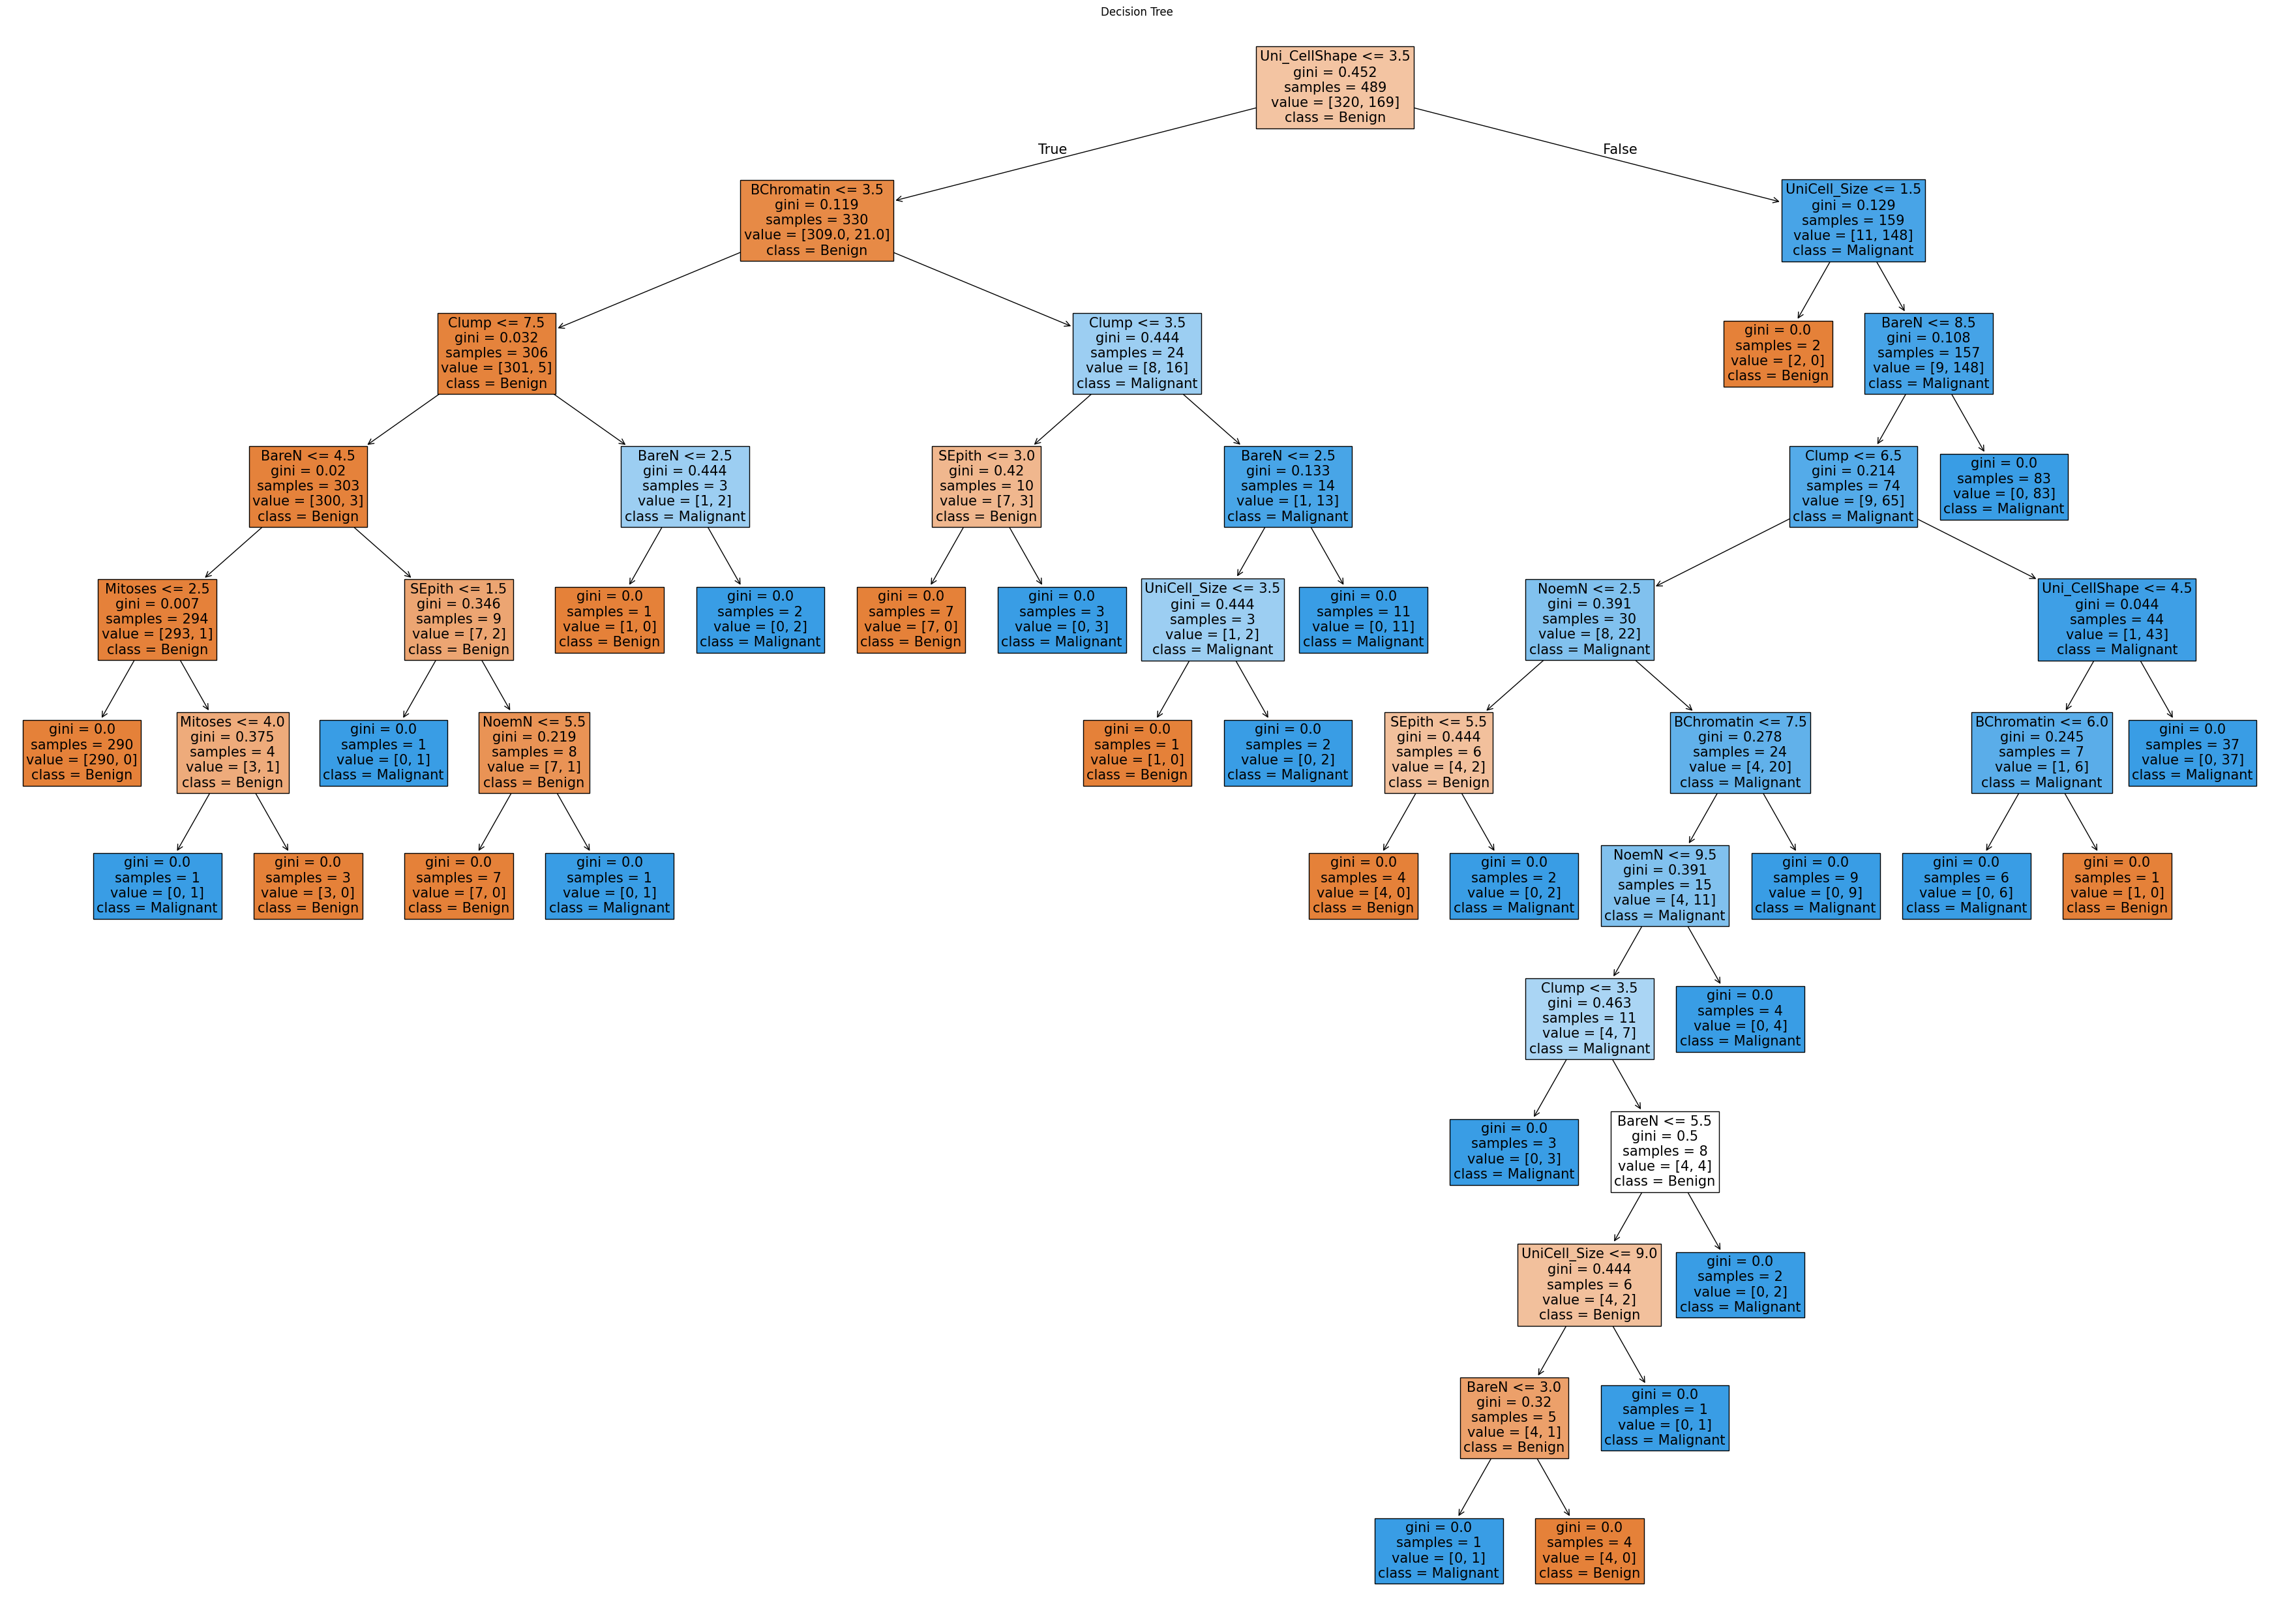

In [14]:
dtc = DecisionTreeClassifier(random_state=26)
dtc.fit(X_train, y_train)
plt.figure(figsize=(35,25))
plot_tree(dtc, feature_names=list(X.columns), class_names=['Benign', 'Malignant'], filled=True, fontsize=15)
plt.title("Decision Tree")
plt.tight_layout()
plt.show()

In [13]:
depths = np.arange(1,12)  # take random values instead of np.arange
splits = np.arange(2,50)
leaves=np.arange(1,50)
scores=[]

for d in tqdm(depths):
    for s in splits:
        for l in leaves:
            dtc = DecisionTreeClassifier(random_state=26, max_depth=d, min_samples_split=s, min_samples_leaf=l)
            
            dtc.fit(X_train, y_train)
            y_pred = dtc.predict(X_test)
            y_pred_prob = dtc.predict_proba(X_test)
            
            scores.append([d, s, l, accuracy_score(y_test, y_pred), log_loss(y_test, y_pred_prob)])
    
df_scores = pd.DataFrame(scores, columns=['Depth', 'Splits', 'Leaves', 'Accuracy', 'log_loss' ])
df_scores.sort_values(['log_loss'], ascending=True).head()

100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [03:16<00:00, 17.89s/it]


,Depth,Splits,Leaves,Accuracy,log_loss
3513,2,25,35,0.895238,0.199964
3263,2,20,30,0.895238,0.199964
3264,2,20,31,0.895238,0.199964
2771,2,10,28,0.895238,0.199964
2772,2,10,29,0.895238,0.199964


# Best Tree

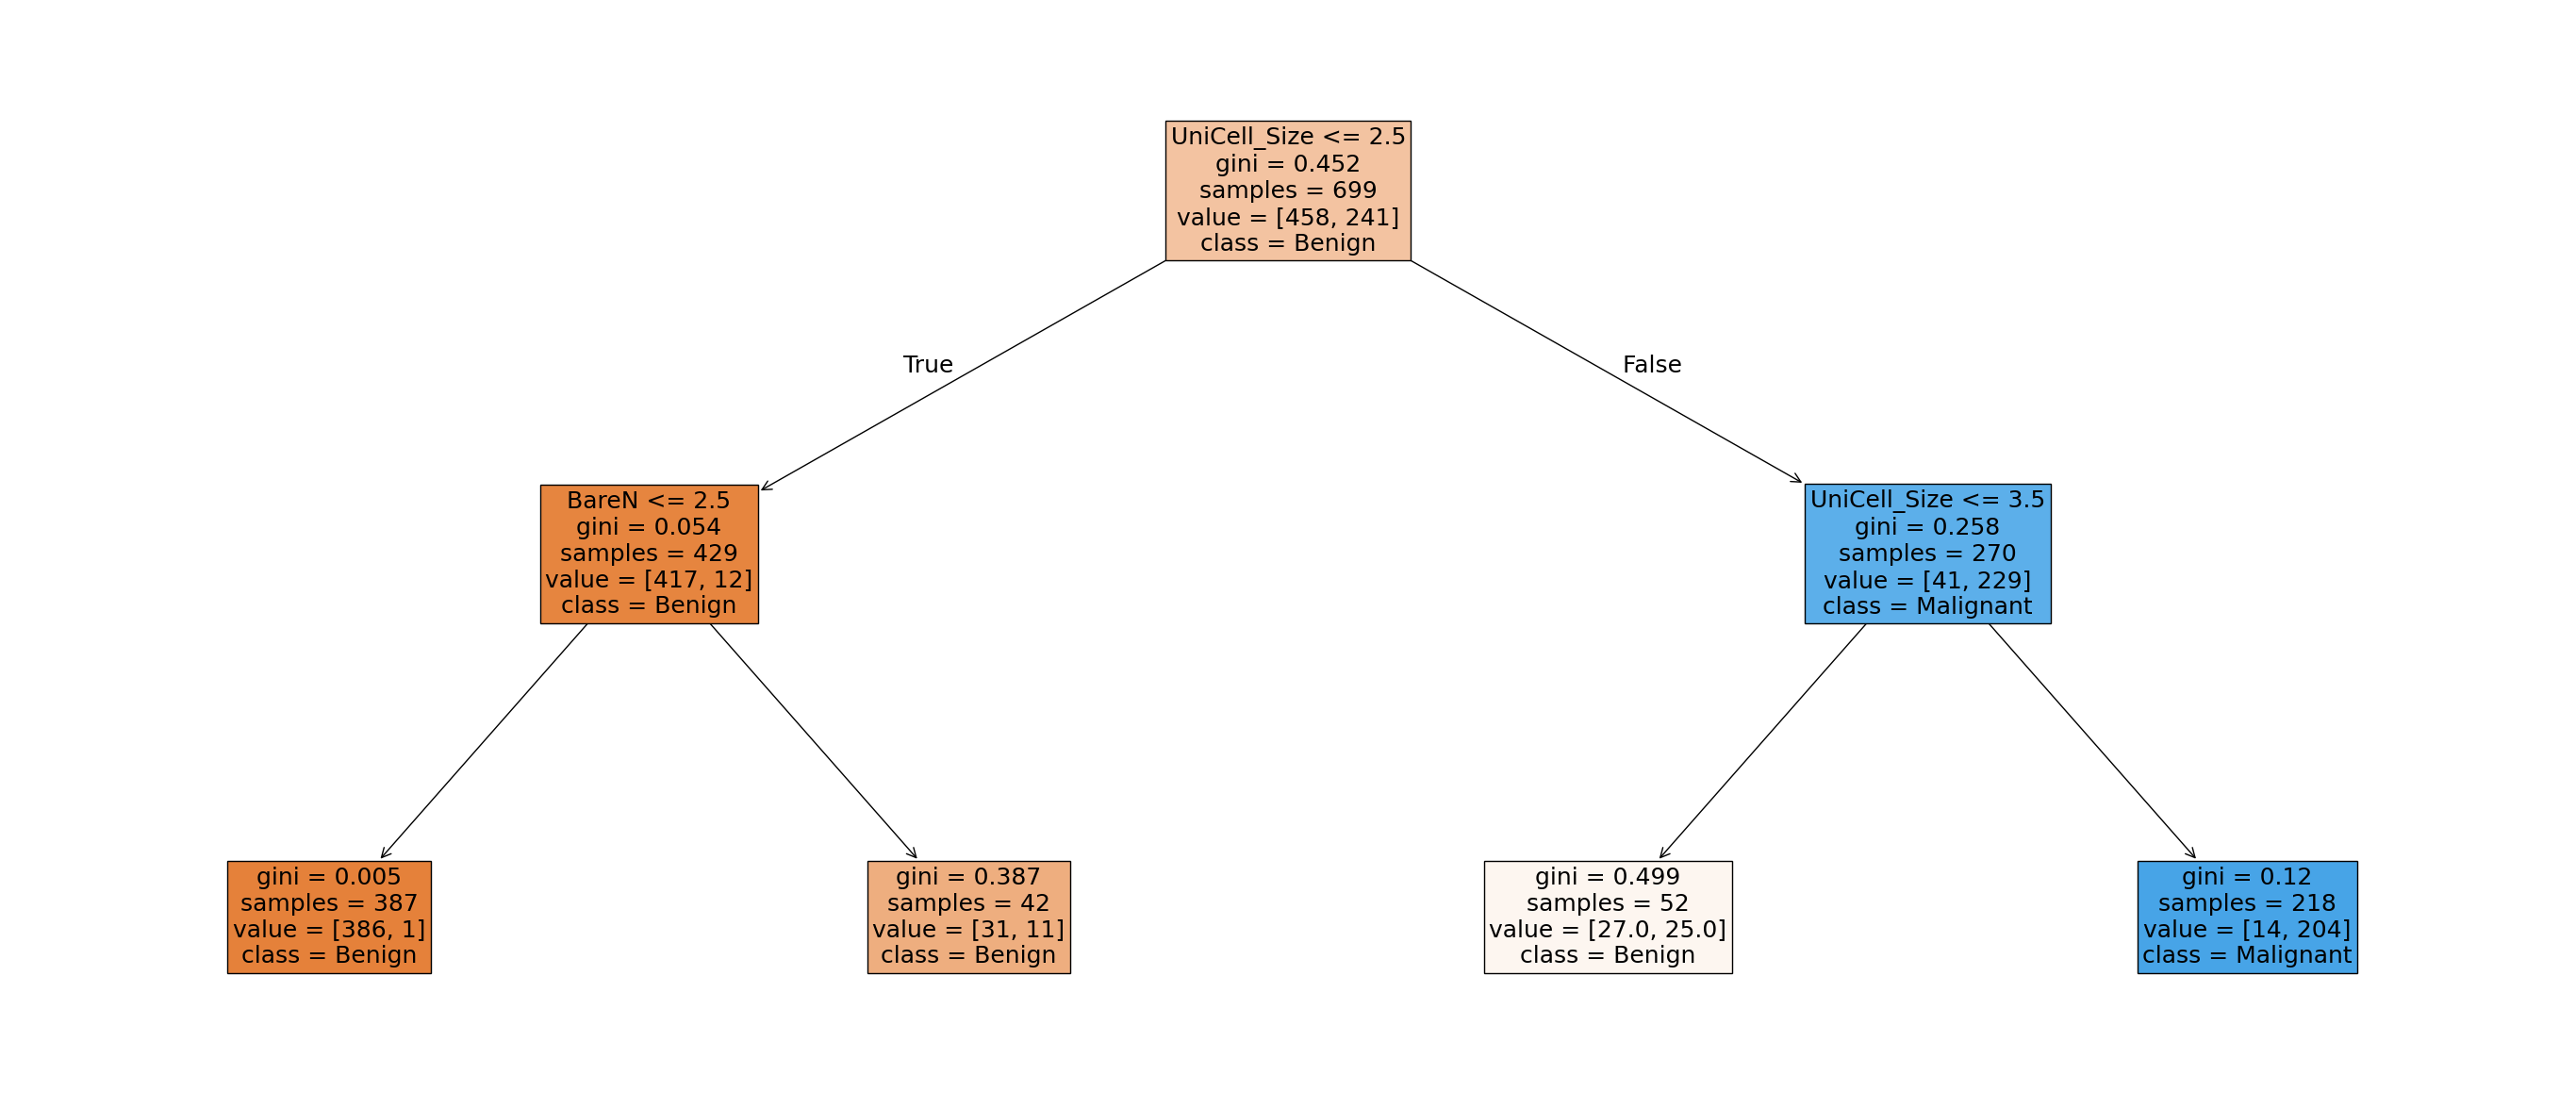

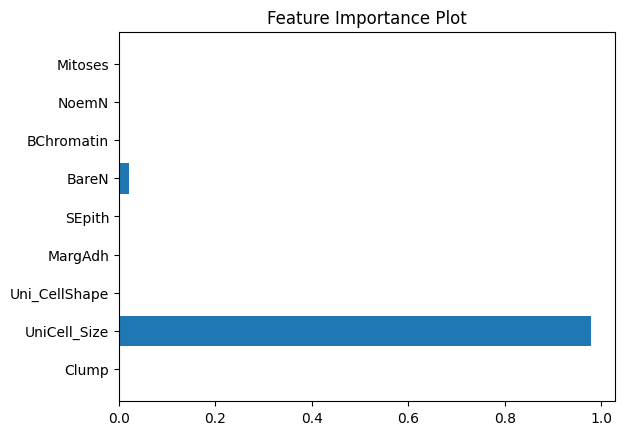

In [19]:
bm =  DecisionTreeClassifier(random_state=26, max_depth=2, min_samples_split=25, min_samples_leaf=35)
bm.fit(X,y)
plt.figure(figsize=(35,15))
plot_tree(bm, feature_names=list(X.columns), class_names=['Benign', 'Malignant'], filled=True, fontsize=18)
plt.show()

df_imp = pd.DataFrame({'feature':X.columns, 'importance':bm.feature_importances_})
plt.barh(df_imp['feature'], df_imp['importance'])
plt.title("Feature Importance Plot")
plt.show()

# Human Resuorce Dataset

In [23]:
hr = pd.read_csv('D:/Machine_Learning/Cases/HumanResource/HR_comma_sep.csv')

X , y = hr.drop('left', axis=1), hr['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=26, stratify= hr['left'])

In [26]:
ohe=OneHotEncoder(sparse_output=False,drop="first").set_output(transform="pandas")

trans = ColumnTransformer(transformers=[("OHE", ohe, make_column_selector(dtype_include=object))], remainder="passthrough",
                            verbose_feature_names_out=False).set_output(transform="pandas")

X_trn_ohe = trans.fit_transform(X_train)
X_tst_ohe = trans.transform(X_test)

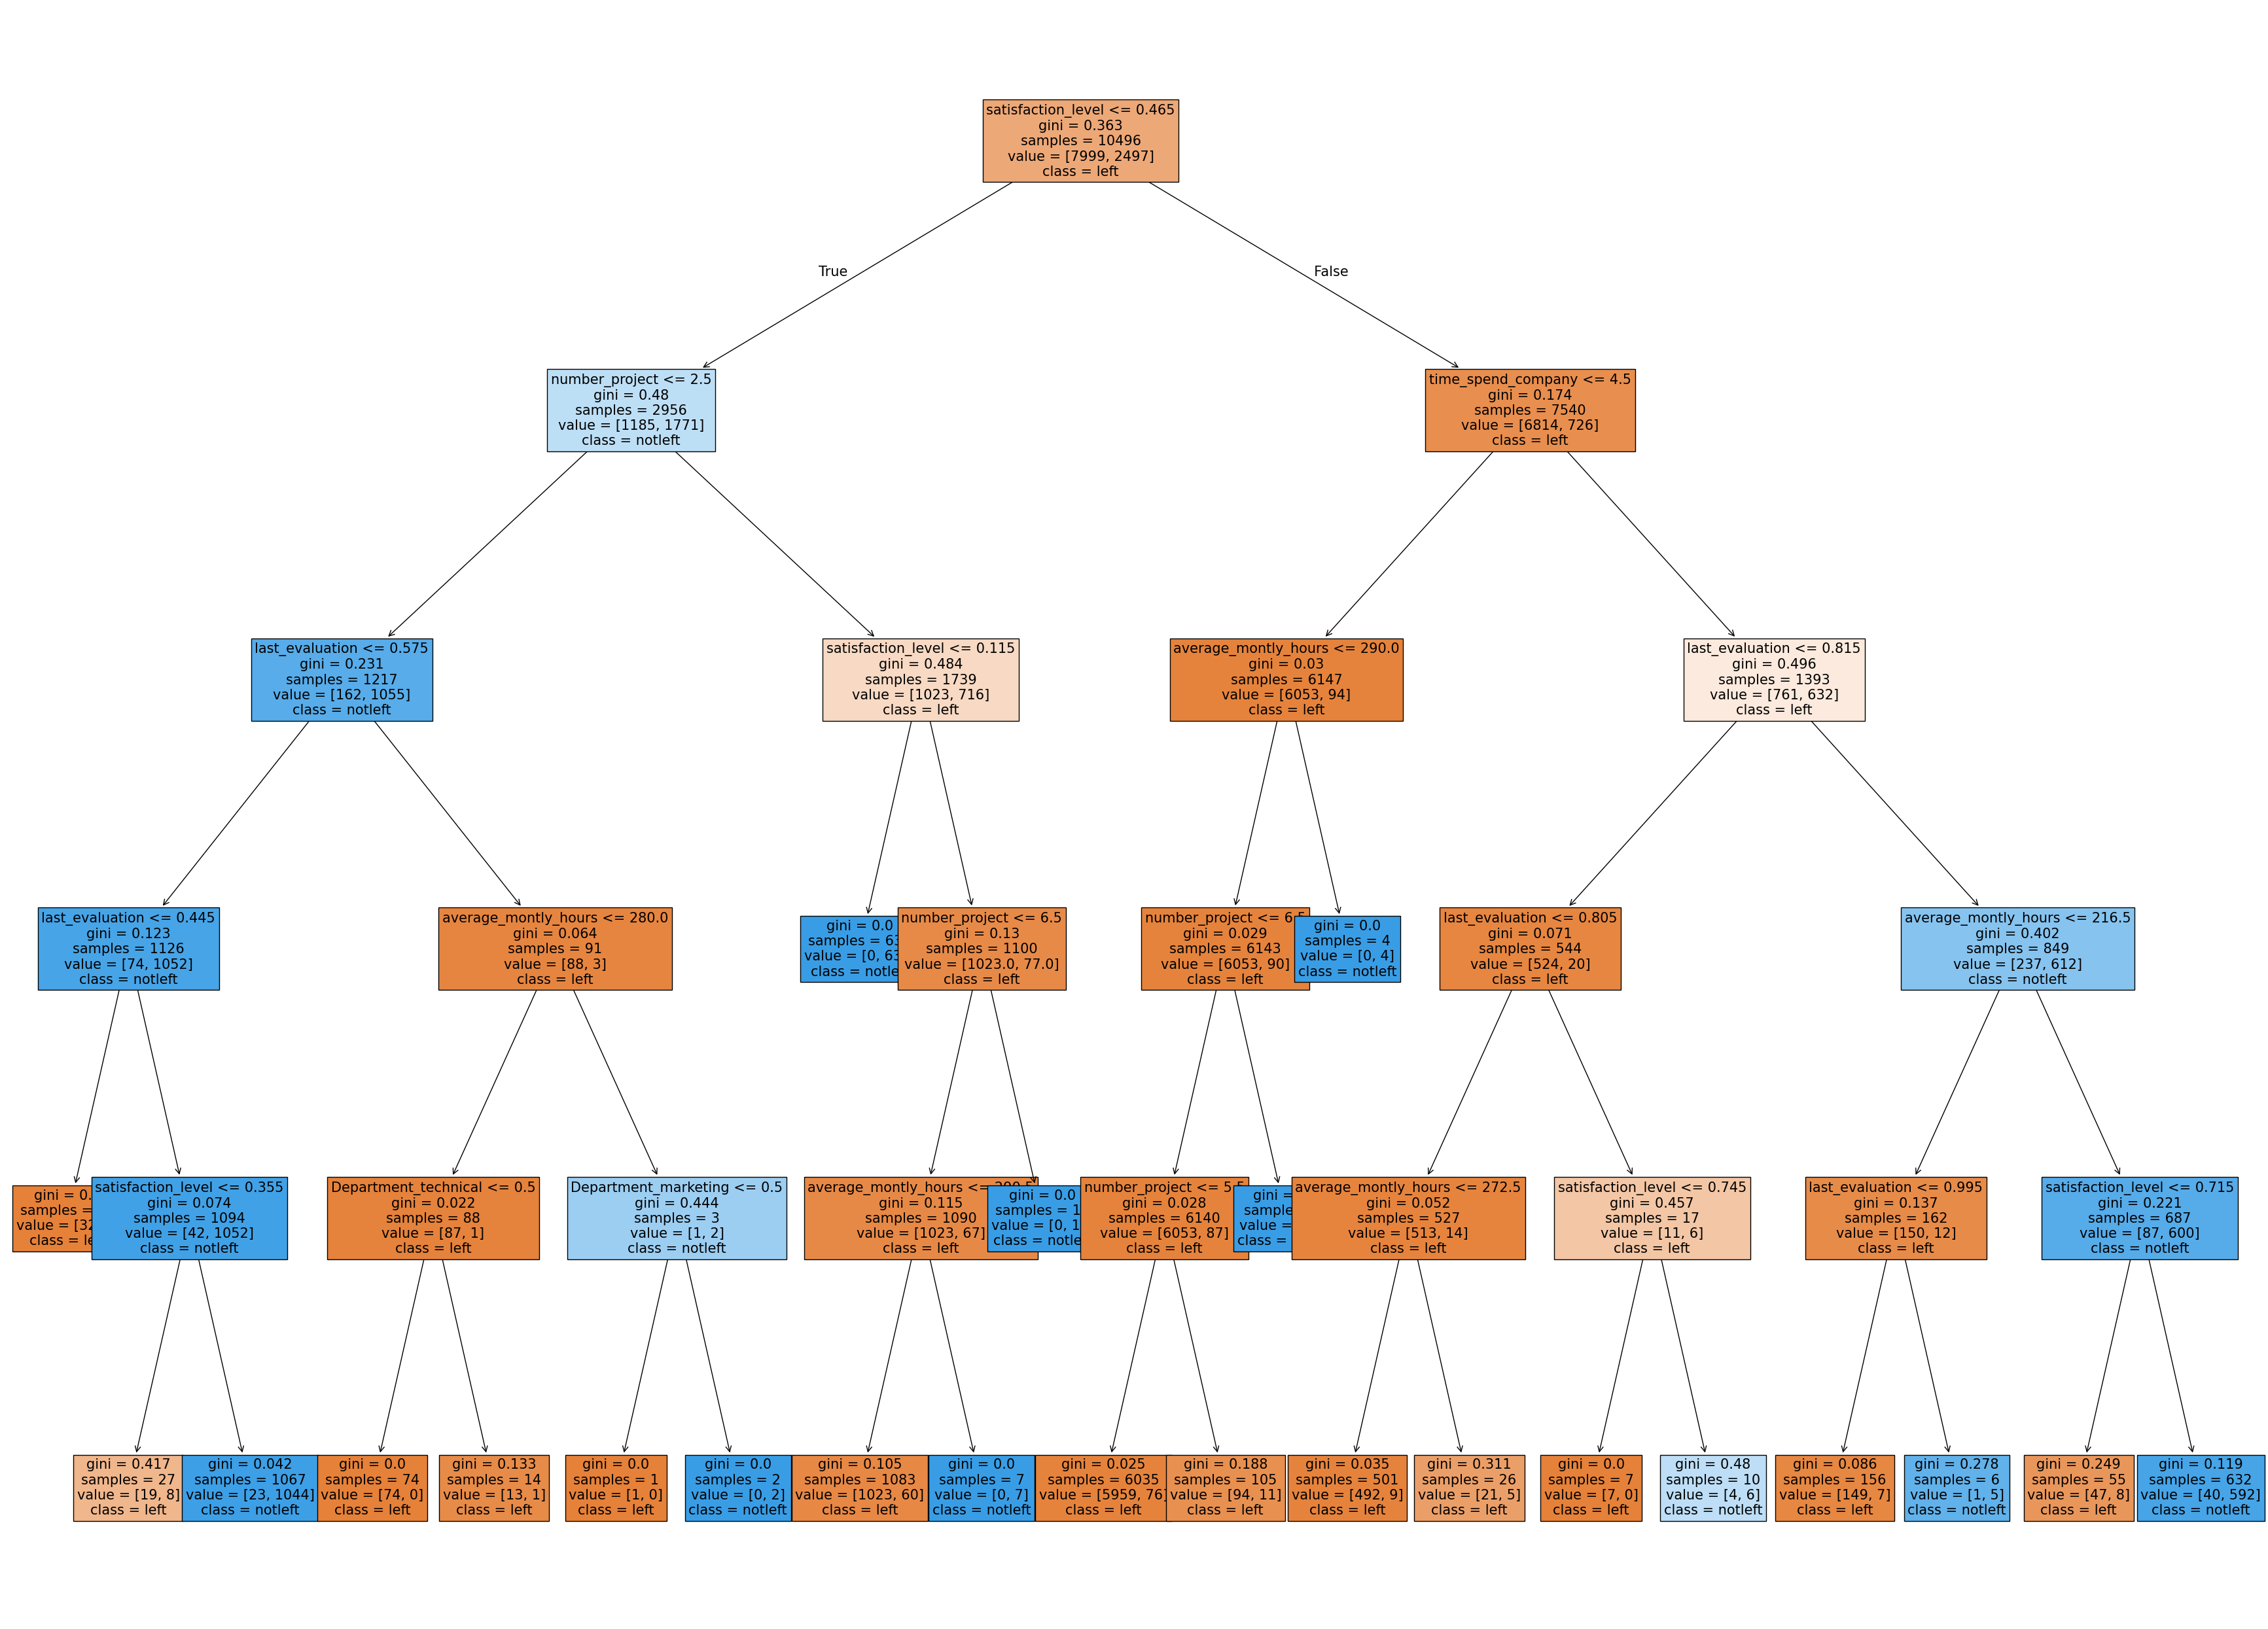

In [49]:
dtc = DecisionTreeClassifier(random_state=26,max_depth=5)
dtc.fit(X_trn_ohe, y_train)
plt.figure(figsize=(35,25))
plot_tree(dtc, feature_names=list(X_trn_ohe.columns), class_names=['left', 'notleft'], filled=True, fontsize=15)
plt.tight_layout()
plt.show()

In [38]:
depths = [1,2,3,5,None]  # take random values instead of np.arange
splits = [2,4,8,10,20,30,50,100]
leaves= [1,4,8,10,20,30,50,100]
scores=[]

for d in tqdm(depths):
    for s in splits:
        for l in leaves:
            dtc = DecisionTreeClassifier(random_state=26, max_depth=d, min_samples_split=s, min_samples_leaf=l)
            
            dtc.fit(X_trn_ohe, y_train)
            y_pred = dtc.predict(X_tst_ohe)
            y_pred_prob = dtc.predict_proba(X_tst_ohe)
            
            scores.append([d, s, l, accuracy_score(y_test, y_pred), log_loss(y_test, y_pred_prob)])
    
df_scores = pd.DataFrame(scores, columns=['Depth', 'Splits', 'Leaves', 'Accuracy', 'log_loss' ])
df_scores.sort_values(['log_loss'], ascending=True).head()

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.41s/it]


,Depth,Splits,Leaves,Accuracy,log_loss
248,5.0,100,1,0.971772,0.113100
249,5.0,100,4,0.971549,0.118967
216,5.0,10,1,0.971994,0.118982
208,5.0,8,1,0.971994,0.118982
200,5.0,4,1,0.971994,0.118982


# Best Tree

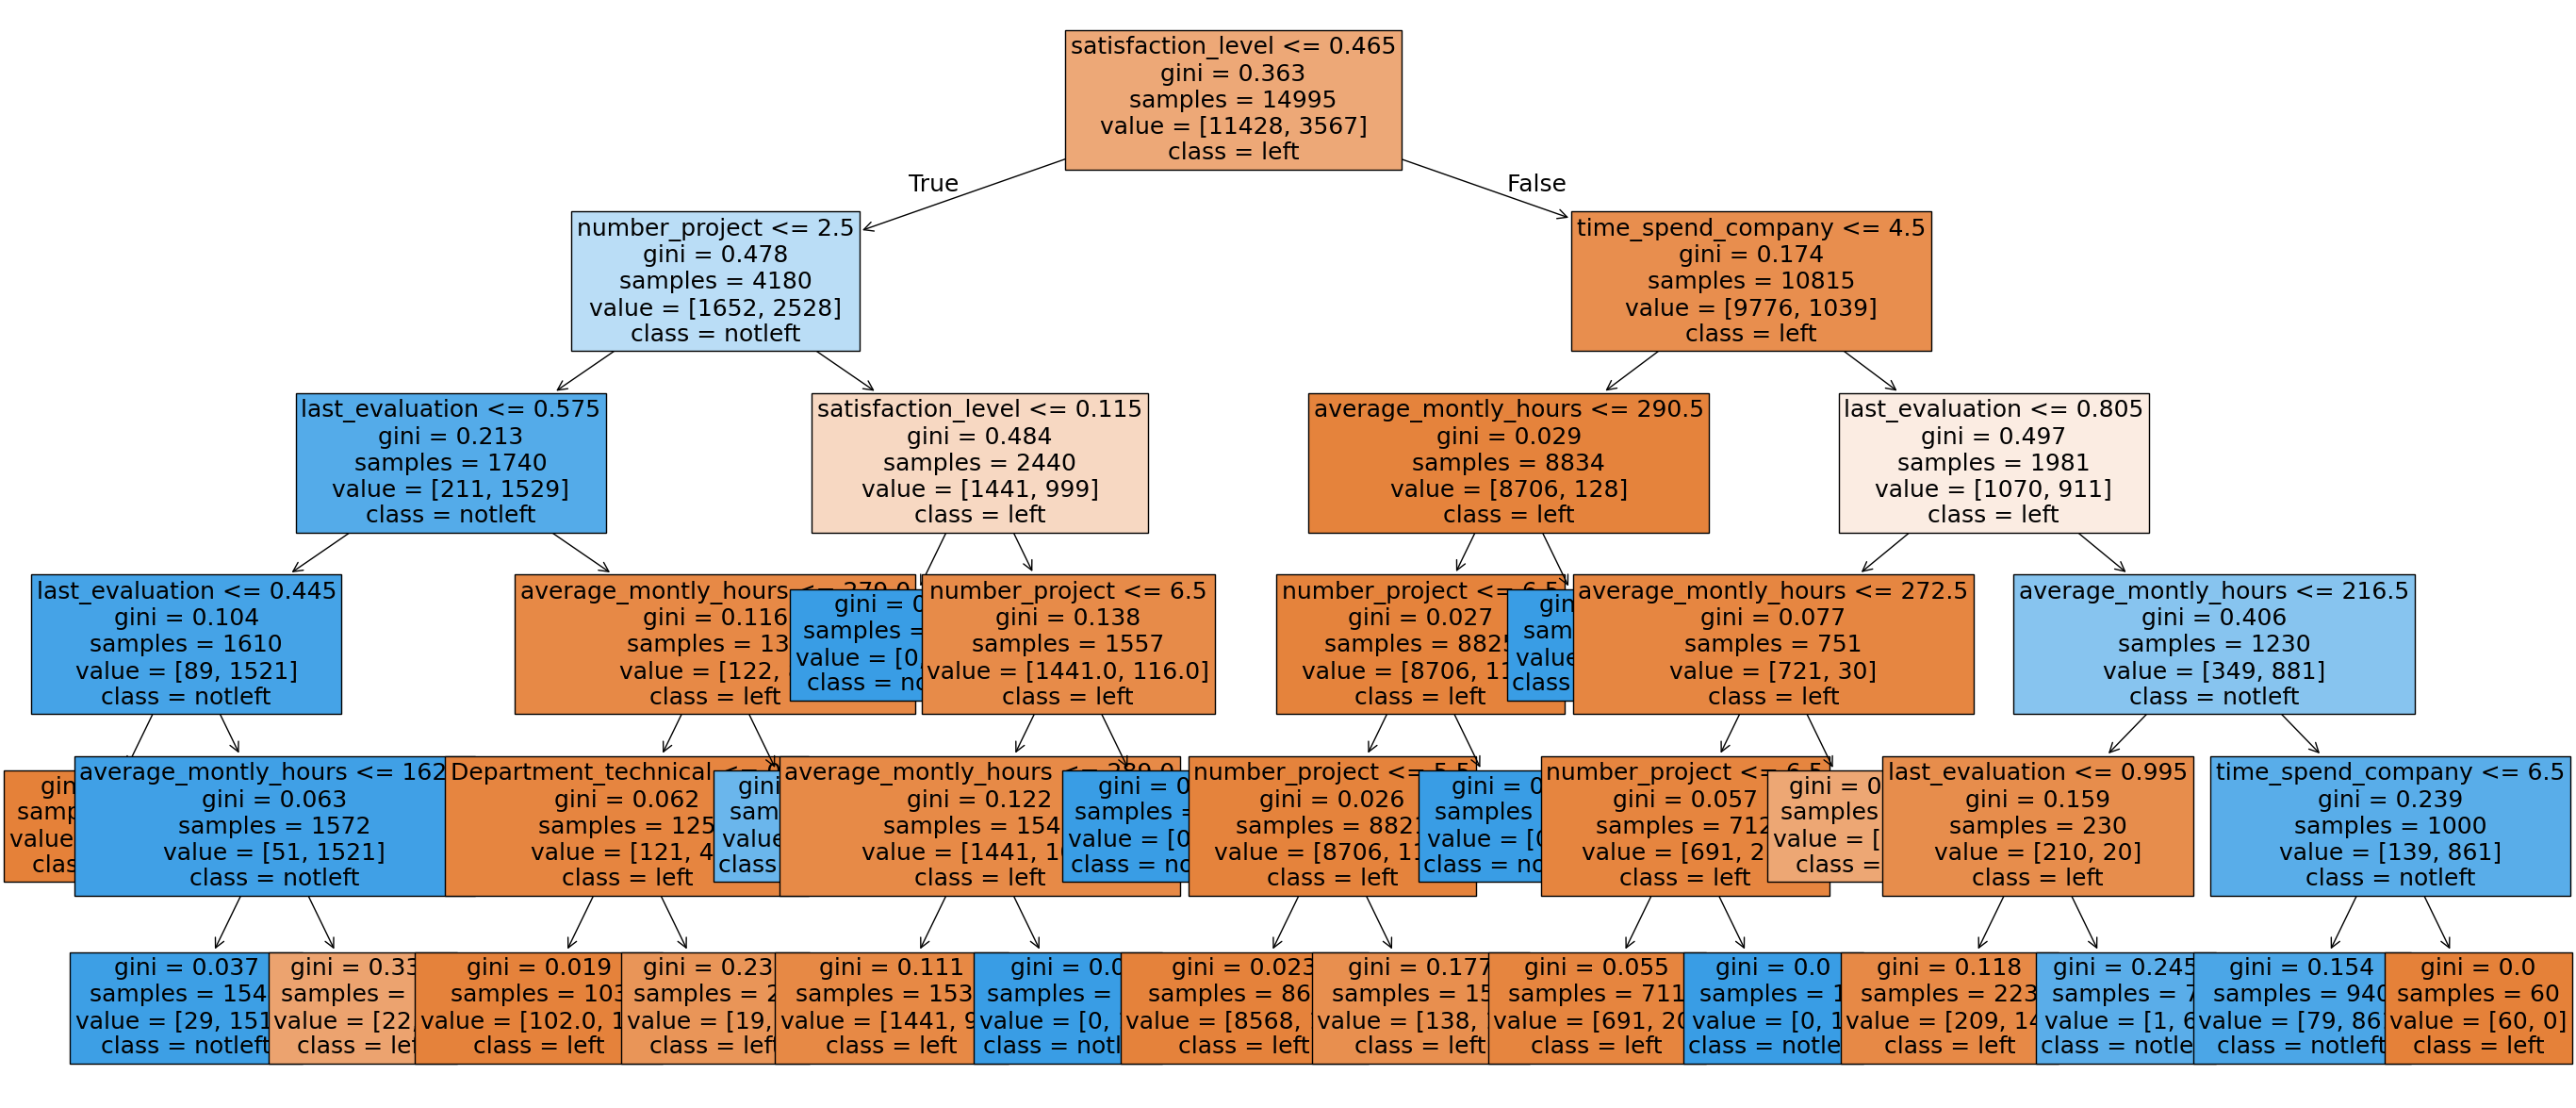

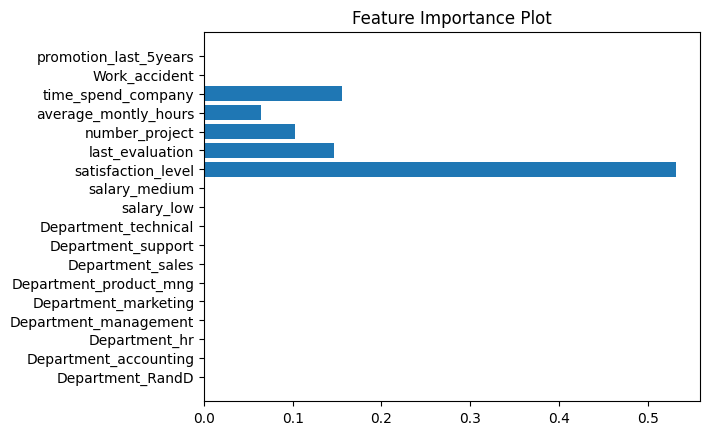

In [44]:
bm =  DecisionTreeClassifier(random_state=26, max_depth=5, min_samples_split=100, min_samples_leaf=1)
X_ohe = trans.fit_transform(X)
bm.fit(X_ohe,y)
plt.figure(figsize=(35,15))
plot_tree(bm, feature_names=list(X_ohe.columns), class_names=['left', 'notleft'], filled=True, fontsize=18)
plt.show()

df_imp = pd.DataFrame({'feature':X_ohe.columns, 'importance':bm.feature_importances_})
plt.barh(df_imp['feature'], df_imp['importance'])
plt.title("Feature Importance Plot")
plt.show()

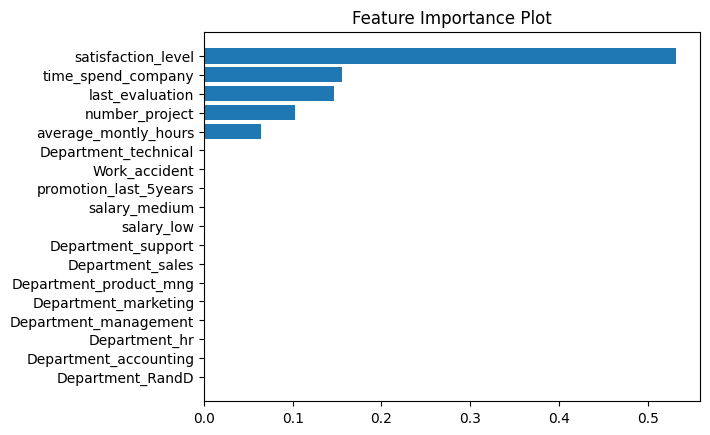

In [48]:
# sort importances
df_imp = pd.DataFrame({'feature':X_ohe.columns, 'importance':bm.feature_importances_})
df_imp = df_imp.sort_values('importance')
plt.barh(df_imp['feature'], df_imp['importance'])
plt.title("Feature Importance Plot")
plt.show()